2 - Analise exploratoria

Estatísticas
count    200.000000
mean     170.982797
std       16.117249
min      130.364739
25%      163.911076
50%      169.966465
75%      175.416255
max      234.166370
dtype: float64
Assimetria: 1.54

3 - Visualização do histograma corrompido



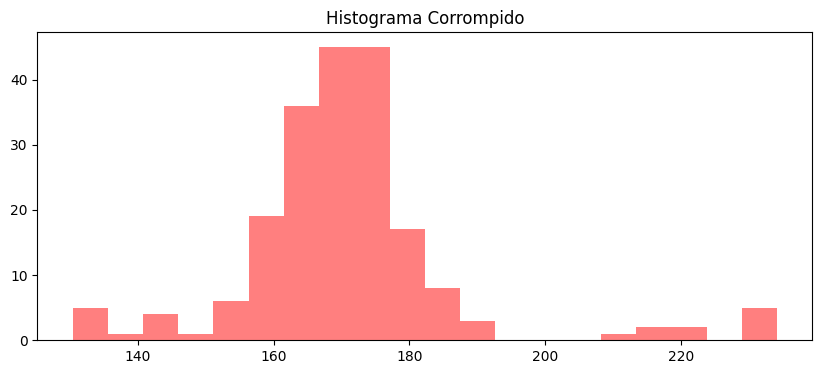

4 - Detecção de Outliers com Boxplot e AIQ


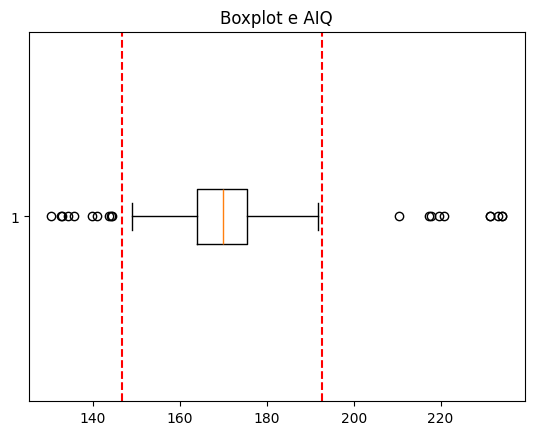

Intervalo de confiança: [146.65 a 192.67]

5 - Eliminação de Outliers

outliers removidos: 20

6 - Histograma Final (Dados Limpos)


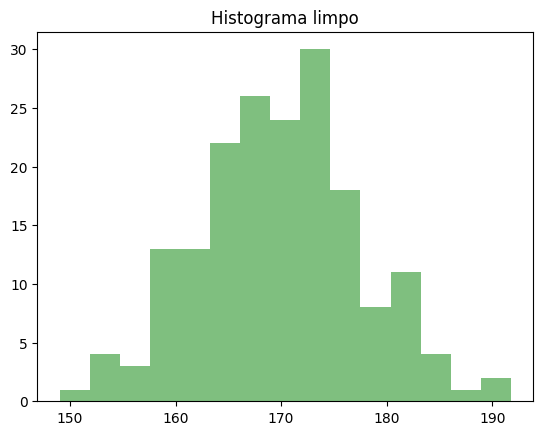

 7 - Conclusão

Feito a analise, notamos que a presença de outliers na base de dados podem distorcer significamente as estatisticas descritivas assim sendo o tratamento de outliers com bloxplot e AIQ é indispensavel, garantido que os casos raros não comprometam a interpretaçao dos dados estudados


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


np.random.seed(42)
alturas = np.random.normal(170, 8, 180) 
outliers_pequenos = np.random.uniform(130,145,10)
outliers_grandes = np.random.uniform(210,235, 10)
dados = pd.Series(np.concatenate([alturas, outliers_pequenos, outliers_grandes]))

print("2 - Analise exploratoria\n")
print("Estatísticas")
print(dados.describe()) 
print(f"Assimetria: {dados.skew():.2f}") 

print("\n3 - Visualização do histograma corrompido\n")
plt.figure(figsize=(10, 4))
plt.hist(dados, bins=20, color='red', alpha=0.5)
plt.title("Histograma Corrompido")
plt.show()

print("4 - Detecção de Outliers com Boxplot e AIQ")
q1 = dados.quantile(0.25)
q3 = dados.quantile(0.75)
aiq = q3 - q1
limite_inf = q1 - 1.5 * aiq
limite_sup = q3 + 1.5 * aiq

plt.boxplot(dados, vert=False)
plt.axvline(limite_inf, color='r', linestyle='--')
plt.axvline(limite_sup, color='r', linestyle='--')
plt.title("Boxplot e AIQ")
plt.show()
print(f"Intervalo de confiança: [{limite_inf:.2f} a {limite_sup:.2f}]\n")

print("5 - Eliminação de Outliers\n")
dados_limpos = dados[(dados >= limite_inf) & (dados <= limite_sup)]
print(f"outliers removidos: {len(dados) - len(dados_limpos)}\n") 

print("6 - Histograma Final (Dados Limpos)")
plt.hist(dados_limpos, bins=15, color='green', alpha=0.5)
plt.title("Histograma limpo")
plt.show()

print(" 7 - Conclusão\n")
print("Feito a analise, notamos que a presença de outliers na base de dados podem distorcer significamente as estatisticas descritivas assim sendo o tratamento de outliers com bloxplot e AIQ é indispensavel, garantido que os casos raros não comprometam a interpretaçao dos dados estudados")